# kv → p_c Steady-State Mapping

Maps valve opening (kv) to steady-state chamber pressure (p_c).
Used to determine the correct kv range for reference generation in data collection.

In [ ]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.abspath(''), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from model import Monoprop_sim

# System parameters (must match collect_data.py)
H_SIM = 1e-4; TV = 0.1; DP = 0.01; LP = 0.5; VC = 1e-3; DTH = 0.03
FLUID = 'C2H6O'; P_BC = 30e5; T_PROP = 293

sim = Monoprop_sim(H_SIM, TV, DP, LP, VC, DTH, FLUID, P_BC, T_PROP)
ig  = [0.5, 0.5, 25e5, 20e5, 0.7, 100, 1800]

# Sweep kv and compute steady-state p_c
kv_vals = np.linspace(0.10, 0.95, 80)
kv_ok, p_ok = [], []

for kv in kv_vals:
    sol = sim.steady_solution(kv, ig)
    if sol.success:
        kv_ok.append(kv)
        p_ok.append(sol.x[3] / 1e5)   # Pa → bar

kv_ok = np.array(kv_ok)
p_ok  = np.array(p_ok)

print(f"Feasible kv range:  [{kv_ok.min():.3f}, {kv_ok.max():.3f}]")
print(f"p_c range:          [{p_ok.min():.2f}, {p_ok.max():.2f}] bar")

In [2]:
# Operating bounds
P_MIN = 9.0    # bar
P_MAX = 15.5   # bar

# Find kv values corresponding to P_MIN and P_MAX
kv_at_pmin = kv_ok[np.argmin(np.abs(p_ok - P_MIN))]
kv_at_pmax = kv_ok[np.argmin(np.abs(p_ok - P_MAX))]

print(f"kv for {P_MIN} bar:  {kv_at_pmin:.4f}")
print(f"kv for {P_MAX} bar:  {kv_at_pmax:.4f}")
print(f"\nReference generation should use kv ∈ [{kv_at_pmin:.4f}, {kv_at_pmax:.4f}]")

kv for 9.0 bar:  0.4013
kv for 15.5 bar:  0.8316

Reference generation should use kv ∈ [0.4013, 0.8316]


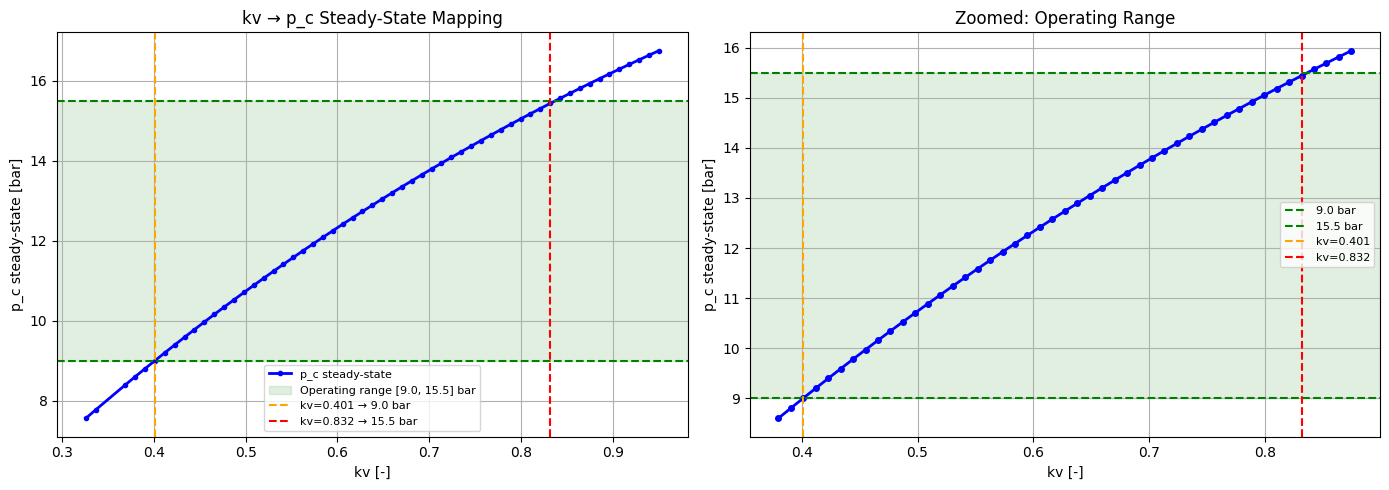

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full curve ---
axes[0].plot(kv_ok, p_ok, 'b-o', markersize=3, lw=2, label='p_c steady-state')
axes[0].axhspan(P_MIN, P_MAX, alpha=0.12, color='green', label=f'Operating range [{P_MIN}, {P_MAX}] bar')
axes[0].axhline(P_MIN, c='green', ls='--', lw=1.5)
axes[0].axhline(P_MAX, c='green', ls='--', lw=1.5)
axes[0].axvline(kv_at_pmin, c='orange', ls='--', lw=1.5, label=f'kv={kv_at_pmin:.3f} → {P_MIN} bar')
axes[0].axvline(kv_at_pmax, c='red',    ls='--', lw=1.5, label=f'kv={kv_at_pmax:.3f} → {P_MAX} bar')
axes[0].set_xlabel('kv [-]')
axes[0].set_ylabel('p_c steady-state [bar]')
axes[0].set_title('kv → p_c Steady-State Mapping')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# --- Right: zoomed to operating range ---
mask = (p_ok >= P_MIN - 0.5) & (p_ok <= P_MAX + 0.5)
axes[1].plot(kv_ok[mask], p_ok[mask], 'b-o', markersize=4, lw=2)
axes[1].axhspan(P_MIN, P_MAX, alpha=0.12, color='green')
axes[1].axhline(P_MIN, c='green', ls='--', lw=1.5, label=f'{P_MIN} bar')
axes[1].axhline(P_MAX, c='green', ls='--', lw=1.5, label=f'{P_MAX} bar')
axes[1].axvline(kv_at_pmin, c='orange', ls='--', lw=1.5, label=f'kv={kv_at_pmin:.3f}')
axes[1].axvline(kv_at_pmax, c='red',    ls='--', lw=1.5, label=f'kv={kv_at_pmax:.3f}')
axes[1].set_xlabel('kv [-]')
axes[1].set_ylabel('p_c steady-state [bar]')
axes[1].set_title('Zoomed: Operating Range')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
# Lookup table: print all kv → p_c pairs in operating range
print(f"{'kv':>8}  {'p_c [bar]':>12}")
print('-' * 25)
for kv, p in zip(kv_ok, p_ok):
    marker = ' ← operating range' if P_MIN <= p <= P_MAX else ''
    print(f"{kv:8.4f}  {p:12.3f}{marker}")

      kv     p_c [bar]
-------------------------
  0.3259         7.561
  0.3367         7.774
  0.3690         8.399
  0.3797         8.603
  0.3905         8.805
  0.4013         9.005 ← operating range
  0.4120         9.202 ← operating range
  0.4228         9.398 ← operating range
  0.4335         9.591 ← operating range
  0.4443         9.783 ← operating range
  0.4551         9.972 ← operating range
  0.4658        10.159 ← operating range
  0.4766        10.344 ← operating range
  0.4873        10.528 ← operating range
  0.4981        10.709 ← operating range
  0.5089        10.888 ← operating range
  0.5196        11.065 ← operating range
  0.5304        11.241 ← operating range
  0.5411        11.414 ← operating range
  0.5519        11.586 ← operating range
  0.5627        11.756 ← operating range
  0.5734        11.923 ← operating range
  0.5842        12.089 ← operating range
  0.5949        12.253 ← operating range
  0.6057        12.416 ← operating range
  0.6165        